# Exposing the Seams: Measuring Topic and Linguistic Bias in Fake News Datasets
### Cross-Dataset Generalization Analysis — Full Pipeline

**Sections:**
1. Setup & Installs
2. Data Loading & Preprocessing
3. Baseline Models (Naive Bayes & Logistic Regression)
4. BiLSTM Model
5. BERT / RoBERTa Fine-tuning
6. Cross-Dataset Transfer Evaluation
7. Topic Bias Analysis (LDA + Jensen-Shannon Divergence)
8. Linguistic Bias Analysis (VOR, Readability, Stylometrics)
9. Bias–Performance Correlation
10. Dataset Bias Scorecard
11. Results Summary Tables

## 1. Setup & Installs

In [ ]:
# Install all required packages
!pip install -q transformers datasets accelerate gensim textstat nltk scikit-learn torch torchtext pandas numpy matplotlib seaborn scipy

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.0 MB/s eta 0:00:00
All packages installed.


In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset as HFDataset

import gensim
from gensim import corpora
from gensim.models import LdaMulticore
from gensim.parsing.preprocessing import STOPWORDS

import textstat
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')

# Reproducibility
SEEDS = [42, 123, 456]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Data Loading & Preprocessing

> **Instructions:** Upload your dataset files to the Colab session, or mount Google Drive. Expected files:
> - `liar_train.tsv`, `liar_test.tsv` (from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip)
> - `ISOT_Fake.csv`, `ISOT_True.csv` (from Kaggle ISOT dataset)
> - `FakeNewsNet_politifact_fake.csv`, `FakeNewsNet_politifact_real.csv`
> - `FakeNewsNet_gossipcop_fake.csv`, `FakeNewsNet_gossipcop_real.csv`

In [ ]:
DATA_DIR = '/content/'  # or your Drive path if datasets are there

def load_liar(data_dir):
    cols = ['id','label','statement','subject','speaker','job','state','party',
            'bt','f','ht','mt','pf','context']
    train = pd.read_csv(os.path.join(data_dir, 'liar_train.tsv'), sep='\t', header=None, names=cols)
    test  = pd.read_csv(os.path.join(data_dir, 'liar_test.tsv'),  sep='\t', header=None, names=cols)

    # Collapse 6-class to binary: real = true/mostly-true, fake = everything else
    real_labels = {'true', 'mostly-true'}
    for df in [train, test]:
        df['binary_label'] = df['label'].apply(lambda x: 0 if x in real_labels else 1)
        df['text'] = df['statement'].fillna('')

    return train[['text','binary_label']], test[['text','binary_label']]


# ─────────────────────────────────────────────────────────────────────────────
# ISOT dataset
# ─────────────────────────────────────────────────────────────────────────────
def load_isot(data_dir):
    fake = pd.read_csv(os.path.join(data_dir, 'ISOT_Fake.csv'))
    real = pd.read_csv(os.path.join(data_dir, 'ISOT_True.csv'))
    fake['binary_label'] = 1
    real['binary_label'] = 0
    df = pd.concat([fake, real], ignore_index=True)
    df['text'] = (df['title'].fillna('') + ' ' + df['text'].fillna('')).str.strip()
    df = df.sample(n=8000, random_state=42).reset_index(drop=True)# shuffle
    split = int(0.8 * len(df))
    return df[:split][['text','binary_label']], df[split:][['text','binary_label']]


# ─────────────────────────────────────────────────────────────────────────────
# FakeNewsNet (PolitiFact and GossipCop)
# ─────────────────────────────────────────────────────────────────────────────
def load_fakenewsnet(data_dir, subset='politifact'):
    fake = pd.read_csv(os.path.join(data_dir, f'FakeNewsNet_{subset}_fake.csv'))
    real = pd.read_csv(os.path.join(data_dir, f'FakeNewsNet_{subset}_real.csv'))
    fake['binary_label'] = 1
    real['binary_label'] = 0
    df = pd.concat([fake, real], ignore_index=True)
    text_col = 'text' if 'text' in df.columns else 'title'
    df['text'] = df[text_col].fillna('')
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    if subset == 'gossipcop' and len(df) > 8000:   # ← ADD THIS
        df = df.sample(n=8000, random_state=42)     # ← AND THIS
    split = int(0.8 * len(df))
    return df[:split][['text','binary_label']], df[split:][['text','binary_label']]

# ─────────────────────────────────────────────────────────────────────────────
# Load all datasets
# ─────────────────────────────────────────────────────────────────────────────
liar_train,   liar_test   = load_liar(DATA_DIR)
isot_train,   isot_test   = load_isot(DATA_DIR)
fnn_pf_train, fnn_pf_test = load_fakenewsnet(DATA_DIR, 'politifact')
fnn_gc_train, fnn_gc_test = load_fakenewsnet(DATA_DIR, 'gossipcop')

DATASETS = {
    'LIAR':    (liar_train,   liar_test),
    'ISOT':    (isot_train,   isot_test),
    'FNN-PF':  (fnn_pf_train, fnn_pf_test),
    'FNN-GC':  (fnn_gc_train, fnn_gc_test),
}

for name, (train, test) in DATASETS.items():
    print(f'{name}: train={len(train):,}  test={len(test):,}  '
          f'fake%={train["binary_label"].mean()*100:.1f}%')

LIAR: train=10,240  test=1,267  fake%=64.5%
ISOT: train=6,400  test=1,600  fake%=52.5%
FNN-PF: train=844  test=212  fake%=41.8%
FNN-GC: train=6,400  test=1,600  fake%=24.3%


In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/fakenews_checkpoint.pkl', 'rb') as f:
    checkpoint = pickle.load(f)

baseline_results = checkpoint['baseline_results']
bilstm_results   = checkpoint['bilstm_results']
transformer_results = {}  # still to do

print('Baseline pairs loaded:', len(baseline_results))
print('BiLSTM pairs loaded:', len(bilstm_results))

Mounted at /content/drive
Baseline pairs loaded: 32
BiLSTM pairs loaded: 16


## 3. Baseline Models — Naive Bayes & Logistic Regression

In [ ]:
def get_baseline_pipelines():
    """Return dict of name -> sklearn pipeline."""
    tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                            sublinear_tf=True, min_df=2)
    return {
        'NaiveBayes': Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2),
                                 max_features=50_000, min_df=2)),
                                ('clf', MultinomialNB())]),
        'LogReg':     Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2),
                                 max_features=50_000, sublinear_tf=True, min_df=2)),
                                ('clf', LogisticRegression(max_iter=1000, C=1.0))]),
    }


def evaluate_sklearn(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'f1':  f1_score(y_test, preds, average='macro'),
        'acc': accuracy_score(y_test, preds),
    }


# Train on each dataset, evaluate on all others (3 seeds)
baseline_results = {}   # (model_name, train_ds, test_ds) -> list of f1 scores

for seed in SEEDS:
    set_seed(seed)
    pipelines = get_baseline_pipelines()

    for train_name, (train_df, _) in DATASETS.items():
        X_train = train_df['text'].tolist()
        y_train = train_df['binary_label'].tolist()

        for model_name, pipe in pipelines.items():
            pipe.fit(X_train, y_train)

            for test_name, (_, test_df) in DATASETS.items():
                X_test = test_df['text'].tolist()
                y_test = test_df['binary_label'].tolist()

                metrics = evaluate_sklearn(pipe, X_test, y_test)
                key = (model_name, train_name, test_name)
                baseline_results.setdefault(key, []).append(metrics['f1'])

# Summarize
print('\nBaseline Results (macro F1, mean ± std):')
print(f'{"Model":<12} {"Train→Test":<20} {"F1":>8}')
print('-' * 45)
for (model, train_ds, test_ds), scores in sorted(baseline_results.items()):
    mean, std = np.mean(scores), np.std(scores)
    marker = ' ← within' if train_ds == test_ds else ''
    print(f'{model:<12} {train_ds+"→"+test_ds:<20} {mean:.3f} ± {std:.3f}{marker}')


Baseline Results (macro F1, mean ± std):
Model        Train→Test                 F1
---------------------------------------------
LogReg       FNN-GC→FNN-GC        0.754 ± 0.000 ← within
LogReg       FNN-GC→FNN-PF        0.421 ± 0.000
LogReg       FNN-GC→ISOT          0.323 ± 0.000
LogReg       FNN-GC→LIAR          0.266 ± 0.000
LogReg       FNN-PF→FNN-GC        0.470 ± 0.000
LogReg       FNN-PF→FNN-PF        0.806 ± 0.000 ← within
LogReg       FNN-PF→ISOT          0.458 ± 0.000
LogReg       FNN-PF→LIAR          0.442 ± 0.000
LogReg       ISOT→FNN-GC          0.203 ± 0.000
LogReg       ISOT→FNN-PF          0.385 ± 0.000
LogReg       ISOT→ISOT            0.993 ± 0.000 ← within
LogReg       ISOT→LIAR            0.450 ± 0.000
LogReg       LIAR→FNN-GC          0.216 ± 0.000
LogReg       LIAR→FNN-PF          0.355 ± 0.000
LogReg       LIAR→ISOT            0.396 ± 0.000
LogReg       LIAR→LIAR            0.558 ± 0.000 ← within
NaiveBayes   FNN-GC→FNN-GC        0.711 ± 0.000 ← within
NaiveBay

## 4. BiLSTM Model

In [ ]:
# Load from Drive every session — no re-download needed
from google.colab import drive
drive.mount('/content/drive')

GLOVE_PATH = '/content/drive/MyDrive/glove.6B.300d.txt'
print('GloVe ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GloVe ready.


In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# ── Vocabulary & Embedding utils ──────────────────────────────────────────────
def build_vocab(texts, max_vocab=30_000):
    counter = Counter()
    for t in texts:
        counter.update(t.lower().split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def load_glove(path, vocab, dim=300):
    emb = np.random.uniform(-0.1, 0.1, (len(vocab), dim)).astype(np.float32)
    emb[0] = 0  # PAD
    hits = 0
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split()
            word = parts[0]
            if word in vocab:
                emb[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                hits += 1
    print(f'GloVe coverage: {hits}/{len(vocab)} ({hits/len(vocab)*100:.1f}%)')
    return torch.tensor(emb)

def texts_to_tensor(texts, vocab, max_len):
    ids, lengths = [], []
    for t in texts:
        tokens = t.lower().split()[:max_len]
        idxs = [vocab.get(tok, 1) for tok in tokens]
        lengths.append(len(idxs))
        idxs += [0] * (max_len - len(idxs))
        ids.append(idxs)
    return torch.tensor(ids, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


# ── Dataset class ─────────────────────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, ids, lengths, labels):
        self.ids, self.lengths, self.labels = ids, lengths, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.ids[i], self.lengths[i], self.labels[i]


# ── BiLSTM architecture ───────────────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, emb_weights, hidden=256, n_layers=2, dropout=0.3):
        super().__init__()
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding.from_pretrained(emb_weights, freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=n_layers,
                            bidirectional=True, batch_first=True,
                            dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, 2)

    def forward(self, ids, lengths):
        x = self.drop(self.embedding(ids))
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # Concatenate last forward and backward hidden states
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.drop(out))


# ── Training & evaluation functions ──────────────────────────────────────────
def train_bilstm(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for ids, lengths, labels in loader:
        ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(ids, lengths)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_bilstm(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for ids, lengths, labels in loader:
        ids, lengths = ids.to(DEVICE), lengths.to(DEVICE)
        preds = model(ids, lengths).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())
    return f1_score(all_labels, all_preds, average='macro')


# ── Main BiLSTM cross-dataset loop ────────────────────────────────────────────
MAX_LEN      = 256   # tokens (use 64 for LIAR claims)
BATCH_SIZE   = 64
EPOCHS       = 5
GLOVE_PATH   = '/content/drive/MyDrive/glove.6B.300d.txt'

bilstm_results = {}

for seed in SEEDS:
    set_seed(seed)

    for train_name, (train_df, _) in DATASETS.items():
        # Build vocab from training corpus
        all_train_texts = train_df['text'].tolist()
        vocab = build_vocab(all_train_texts)
        emb_weights = load_glove(GLOVE_PATH, vocab)

        # Prepare training data
        max_len = 64 if train_name == 'LIAR' else MAX_LEN
        X_tr, L_tr = texts_to_tensor(all_train_texts, vocab, max_len)
        y_tr = torch.tensor(train_df['binary_label'].tolist(), dtype=torch.long)
        train_loader = DataLoader(TextDataset(X_tr, L_tr, y_tr),
                                  batch_size=BATCH_SIZE, shuffle=True)

        # Build and train model
        model = BiLSTMClassifier(emb_weights).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(EPOCHS):
            loss = train_bilstm(model, train_loader, optimizer, criterion)
            if (epoch + 1) % 2 == 0:
                print(f'  [{train_name}] Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}')

        # Evaluate on all test sets
        for test_name, (_, test_df) in DATASETS.items():
            test_max_len = 64 if test_name == 'LIAR' else MAX_LEN
            X_te, L_te = texts_to_tensor(test_df['text'].tolist(), vocab, test_max_len)
            y_te = torch.tensor(test_df['binary_label'].tolist(), dtype=torch.long)
            test_loader = DataLoader(TextDataset(X_te, L_te, y_te), batch_size=128)
            f1 = eval_bilstm(model, test_loader)
            key = ('BiLSTM', train_name, test_name)
            bilstm_results.setdefault(key, []).append(f1)
            print(f'    {train_name}→{test_name}: F1={f1:.3f}')

print('\nBiLSTM done.')

GloVe coverage: 11125/20068 (55.4%)
  [LIAR] Epoch 2/5  loss=0.5817
  [LIAR] Epoch 4/5  loss=0.2558
    LIAR→LIAR: F1=0.550
    LIAR→ISOT: F1=0.489
    LIAR→FNN-PF: F1=0.462
    LIAR→FNN-GC: F1=0.487
GloVe coverage: 19498/30000 (65.0%)
  [ISOT] Epoch 2/5  loss=0.0236
  [ISOT] Epoch 4/5  loss=0.0025
    ISOT→LIAR: F1=0.399
    ISOT→ISOT: F1=1.000
    ISOT→FNN-PF: F1=0.338
    ISOT→FNN-GC: F1=0.208
GloVe coverage: 2588/3356 (77.1%)
  [FNN-PF] Epoch 2/5  loss=0.3468
  [FNN-PF] Epoch 4/5  loss=0.1491
    FNN-PF→LIAR: F1=0.480
    FNN-PF→ISOT: F1=0.485
    FNN-PF→FNN-PF: F1=0.847
    FNN-PF→FNN-GC: F1=0.308
GloVe coverage: 13516/26727 (50.6%)
  [FNN-GC] Epoch 2/5  loss=0.2981
  [FNN-GC] Epoch 4/5  loss=0.1199
    FNN-GC→LIAR: F1=0.352
    FNN-GC→ISOT: F1=0.440
    FNN-GC→FNN-PF: F1=0.574
    FNN-GC→FNN-GC: F1=0.764
GloVe coverage: 11125/20068 (55.4%)
  [LIAR] Epoch 2/5  loss=0.5835
  [LIAR] Epoch 4/5  loss=0.2703
    LIAR→LIAR: F1=0.544
    LIAR→ISOT: F1=0.428
    LIAR→FNN-PF: F1=0.434
    

In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/fakenews_checkpoint.pkl', 'wb') as f:
    pickle.dump({
        'baseline_results': baseline_results,
        'bilstm_results': bilstm_results,
    }, f)
print('Saved!')

Mounted at /content/drive
Saved!


In [ ]:
# Run ONCE to save to Drive
from google.colab import drive
drive.mount('/content/drive')

!wget -q --show-progress https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.300d.txt
!cp glove.6B.300d.txt "/content/drive/MyDrive/glove.6B.300d.txt"
print('Saved to Drive.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
glove.6B.zip.1      100%[===================>] 822.24M  5.06MB/s    in 2m 39s  
replace glove.6B.300d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Saved to Drive.


## 5. BERT / RoBERTa Fine-tuning

> Uses HuggingFace Trainer. GPU strongly recommended.

In [ ]:
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
import evaluate as hf_evaluate

TRANSFORMER_MODELS = {
    'DistilBERT': 'distilbert-base-uncased',
    'RoBERTa':    'roberta-base',
}

def make_hf_dataset(df, tokenizer, max_len=256):
    hf = HFDataset.from_pandas(df[['text','binary_label']].rename(
         columns={'binary_label':'label'}))
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length',
                         max_length=max_len)
    return hf.map(tokenize, batched=True, batch_size=256)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1':       f1_score(labels, preds, average='macro'),
            'accuracy': accuracy_score(labels, preds)}

# ── Don't reset if already loaded from checkpoint ─────────────────────────────
if 'transformer_results' not in globals():
    transformer_results = {}

for model_label, model_id in TRANSFORMER_MODELS.items():
    for seed in SEEDS:
        set_seed(seed)

        for train_name, (train_df, _) in DATASETS.items():

            # ── Skip already completed runs ───────────────────────────────
            already_done = all(
                len(transformer_results.get((model_label, train_name, test_name), [])) > 0
                for test_name in DATASETS.keys()
            )
            if already_done:
                print(f'Skipping {model_label} | seed={seed} | train={train_name} (already done)')
                continue

            print(f'\n=== {model_label} | seed={seed} | train={train_name} ===')

            tokenizer = AutoTokenizer.from_pretrained(model_id)
            max_len   = 128 if train_name == 'LIAR' else 256
            train_hf  = make_hf_dataset(train_df, tokenizer, max_len)

            model = AutoModelForSequenceClassification.from_pretrained(
                model_id, num_labels=2, ignore_mismatched_sizes=True)

            args = TrainingArguments(
                output_dir       = f'/tmp/{model_label}_{train_name}_seed{seed}',
                num_train_epochs              = 2,
                per_device_train_batch_size   = 32,
                per_device_eval_batch_size    = 64,
                learning_rate                 = 2e-5,
                warmup_steps                  = 100,
                weight_decay                  = 0.01,
                eval_strategy                 = 'no',
                save_strategy                 = 'no',
                load_best_model_at_end        = False,
                fp16                          = torch.cuda.is_available(),
                dataloader_num_workers        = 2,
                report_to                     = 'none',
                seed                          = seed,
            )

            trainer = Trainer(
                model            = model,
                args             = args,
                train_dataset    = train_hf,
                compute_metrics  = compute_metrics,
                processing_class = tokenizer,
            )
            trainer.train()

            # ── Evaluate on all test sets ─────────────────────────────────
            for test_name, (_, test_df) in DATASETS.items():
                test_max_len = 128 if test_name == 'LIAR' else 256
                test_hf      = make_hf_dataset(test_df, tokenizer, test_max_len)
                result       = trainer.evaluate(test_hf)
                f1           = result.get('eval_f1', 0)
                key          = (model_label, train_name, test_name)
                transformer_results.setdefault(key, []).append(f1)
                print(f'  {train_name}→{test_name}: F1={f1:.3f}')

            # ── Save checkpoint after every train_name ────────────────────
            with open('/content/drive/MyDrive/fakenews_checkpoint.pkl', 'wb') as f:
                pickle.dump({
                    'baseline_results':    baseline_results,
                    'bilstm_results':      bilstm_results,
                    'transformer_results': transformer_results,
                }, f)
            print('  ✓ checkpoint saved')

            del model, trainer
            torch.cuda.empty_cache()

print('\nTransformer fine-tuning done.')


=== DistilBERT | seed=42 | train=LIAR ===


Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

  FNN-GC→ISOT: F1=0.512


Map:   0%|          | 0/212 [00:00<?, ? examples/s]

  FNN-GC→FNN-PF: F1=0.647


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

  FNN-GC→FNN-GC: F1=0.796
  ✓ checkpoint saved
Skipping RoBERTa | seed=123 | train=LIAR (already done)
Skipping RoBERTa | seed=123 | train=ISOT (already done)
Skipping RoBERTa | seed=123 | train=FNN-PF (already done)
Skipping RoBERTa | seed=123 | train=FNN-GC (already done)
Skipping RoBERTa | seed=456 | train=LIAR (already done)
Skipping RoBERTa | seed=456 | train=ISOT (already done)
Skipping RoBERTa | seed=456 | train=FNN-PF (already done)
Skipping RoBERTa | seed=456 | train=FNN-GC (already done)

Transformer fine-tuning done.


In [ ]:
with open('/content/drive/MyDrive/fakenews_checkpoint.pkl', 'wb') as f:
    pickle.dump({'baseline_results': baseline_results,
                 'bilstm_results': bilstm_results,
                 'transformer_results': transformer_results}, f)
print('Saved:', len(transformer_results), 'runs so far')

Saved: 5 runs so far


In [ ]:
# ── Load checkpoint ────────────────────────────────────────────────────────
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/fakenews_checkpoint.pkl', 'rb') as f:
    ckpt = pickle.load(f)

baseline_results    = ckpt['baseline_results']
bilstm_results      = ckpt['bilstm_results']
transformer_results = ckpt['transformer_results']

print('Baseline runs loaded:',    len(baseline_results))
print('BiLSTM runs loaded:',      len(bilstm_results))
print('Transformer runs loaded:', len(transformer_results))

Mounted at /content/drive
Baseline runs loaded: 32
BiLSTM runs loaded: 16
Transformer runs loaded: 5


## 6. Cross-Dataset Transfer — Summary Table & CPD

In [ ]:
# Merge all results
all_results = {**baseline_results, **bilstm_results, **transformer_results}

DS_NAMES = list(DATASETS.keys())
MODEL_NAMES = ['NaiveBayes', 'LogReg', 'BiLSTM', 'DistilBERT', 'RoBERTa']

def get_f1(model, train_ds, test_ds):
    scores = all_results.get((model, train_ds, test_ds), [])
    if not scores: return np.nan, np.nan
    return np.mean(scores), np.std(scores)

# ── Within-dataset table (Table 2) ───────────────────────────────────────────
print('Table 2: Within-Dataset Macro F1 (mean ± std)\n')
header = f'{"Model":<12}' + ''.join(f'{d:>16}' for d in DS_NAMES)
print(header)
print('-' * len(header))
for m in MODEL_NAMES:
    row = f'{m:<12}'
    for d in DS_NAMES:
        mean, std = get_f1(m, d, d)
        row += f'{mean:.3f}±{std:.3f}'.rjust(16)
    print(row)

# ── Cross-dataset table (Table 3) — RoBERTa ─────────────────────────────────
print('\n\nTable 3: RoBERTa Cross-Dataset Macro F1 (Train→Test)\n')
print(f'{"":>10}' + ''.join(f'{d:>12}' for d in DS_NAMES))
for train_ds in DS_NAMES:
    row = f'{train_ds:<10}'
    for test_ds in DS_NAMES:
        mean, std = get_f1('RoBERTa', train_ds, test_ds)
        tag = '[within]' if train_ds == test_ds else f'{mean:.3f}±{std:.3f}'
        row += tag.rjust(12)
    print(row)

# ── Cross-Dataset Performance Drop (CPD) ─────────────────────────────────────
print('\n\nCross-Dataset Performance Drop (CPD = within_F1 - cross_F1)\n')
cpd_records = []
for m in MODEL_NAMES:
    for train_ds in DS_NAMES:
        within_f1, _ = get_f1(m, train_ds, train_ds)
        for test_ds in DS_NAMES:
            if train_ds == test_ds: continue
            cross_f1, _ = get_f1(m, train_ds, test_ds)
            cpd = within_f1 - cross_f1
            cpd_records.append({'model': m, 'train': train_ds,
                                 'test': test_ds, 'cpd': cpd})

cpd_df = pd.DataFrame(cpd_records)
print(cpd_df.groupby('model')['cpd'].agg(['mean','std']).round(3))

Table 2: Within-Dataset Macro F1 (mean ± std)

Model                   LIAR            ISOT          FNN-PF          FNN-GC
----------------------------------------------------------------------------
NaiveBayes       0.450±0.000     0.954±0.000     0.841±0.000     0.711±0.000
LogReg           0.558±0.000     0.993±0.000     0.806±0.000     0.754±0.000
BiLSTM           0.551±0.006     1.000±0.000     0.835±0.029     0.760±0.004
DistilBERT       0.616±0.000     1.000±0.000     0.664±0.000     0.789±0.000
RoBERTa          0.636±0.000     1.000±0.000     0.630±0.000     0.796±0.000


Table 3: RoBERTa Cross-Dataset Macro F1 (Train→Test)

                  LIAR        ISOT      FNN-PF      FNN-GC
LIAR          [within] 0.343±0.000 0.271±0.000 0.204±0.000
ISOT       0.415±0.000    [within] 0.271±0.000 0.204±0.000
FNN-PF     0.263±0.000 0.400±0.000    [within] 0.560±0.000
FNN-GC     0.484±0.000 0.512±0.000 0.647±0.000    [within]


Cross-Dataset Performance Drop (CPD = within_F1 - cross_F1)



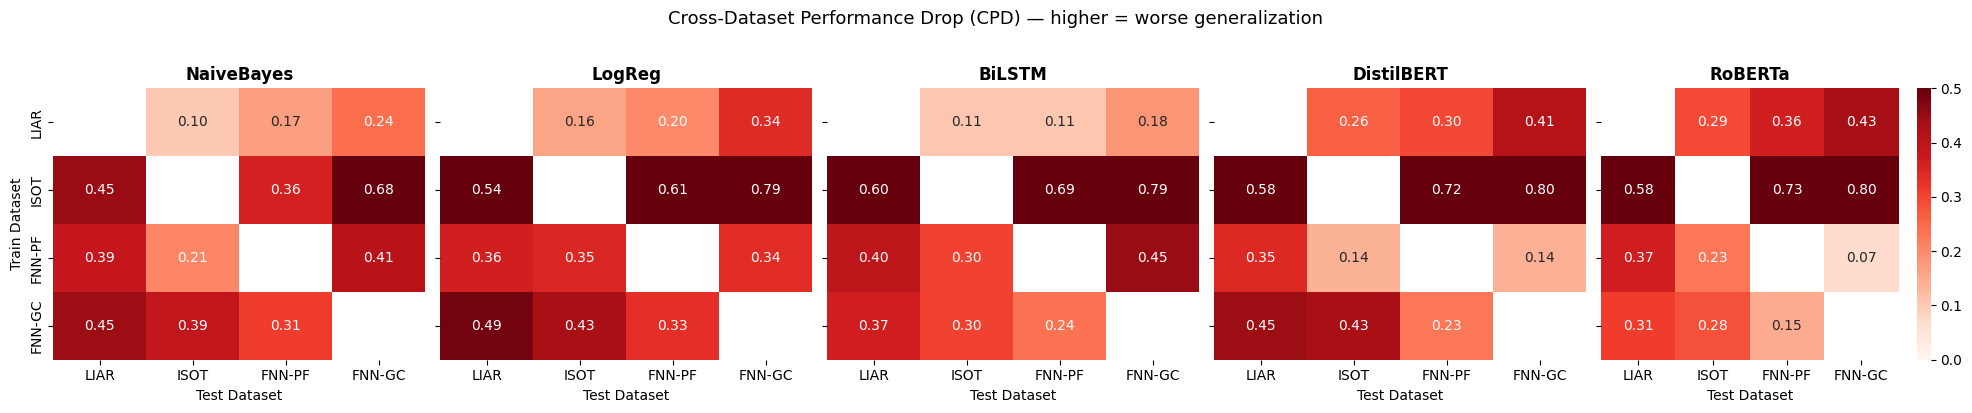

In [ ]:
# ── Heatmap: CPD per model ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(20, 4), sharey=True)

for ax, m in zip(axes, MODEL_NAMES):
    matrix = np.zeros((len(DS_NAMES), len(DS_NAMES)))
    for i, train_ds in enumerate(DS_NAMES):
        within_f1, _ = get_f1(m, train_ds, train_ds)
        for j, test_ds in enumerate(DS_NAMES):
            if i == j:
                matrix[i,j] = np.nan
            else:
                cross_f1, _ = get_f1(m, train_ds, test_ds)
                matrix[i,j] = within_f1 - cross_f1

    sns.heatmap(matrix, ax=ax, annot=True, fmt='.2f', cmap='Reds',
                xticklabels=DS_NAMES, yticklabels=DS_NAMES,
                vmin=0, vmax=0.5, cbar=(ax == axes[-1]))
    ax.set_title(m, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Dataset')
    if ax == axes[0]: ax.set_ylabel('Train Dataset')

plt.suptitle('Cross-Dataset Performance Drop (CPD) — higher = worse generalization',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cpd_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Topic Bias Analysis — LDA + Jensen-Shannon Divergence

In [ ]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import remove_stopwords

N_TOPICS = 20

def preprocess_for_lda(texts):
    return [simple_preprocess(remove_stopwords(t), deacc=True) for t in texts]

# Build combined corpus for LDA
all_texts = []
for name, (train_df, test_df) in DATASETS.items():
    df = pd.concat([train_df, test_df])
    all_texts.extend(df['text'].fillna('').astype(str).tolist())

processed = preprocess_for_lda(all_texts)
dictionary = corpora.Dictionary(processed)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in processed]

print('Training LDA...')
lda = LdaMulticore(corpus, num_topics=N_TOPICS, id2word=dictionary,
                   passes=10, workers=2, random_state=42)
print('LDA trained.')

# Print top words per topic
print('\nTop 8 words per topic:')
for i, topic in lda.print_topics(num_words=8):
    print(f'  Topic {i:>2}: {topic}')

Training LDA...
LDA trained.

Top 8 words per topic:
  Topic  0: 0.021*"minister" + 0.019*"iran" + 0.019*"foreign" + 0.017*"security" + 0.013*"talks" + 0.012*"deal" + 0.012*"the" + 0.011*"international"
  Topic  1: 0.047*"president" + 0.041*"said" + 0.037*"obama" + 0.021*"house" + 0.016*"white" + 0.014*"monday" + 0.014*"administration" + 0.010*"barack"
  Topic  2: 0.028*"said" + 0.022*"wednesday" + 0.016*"city" + 0.016*"official" + 0.015*"the" + 0.014*"group" + 0.013*"state" + 0.013*"al"
  Topic  3: 0.022*"the" + 0.020*"police" + 0.016*"said" + 0.015*"year" + 0.009*"years" + 0.008*"may" + 0.008*"old" + 0.008*"in"
  Topic  4: 0.048*"percent" + 0.017*"texas" + 0.014*"says" + 0.013*"justin" + 0.011*"rate" + 0.011*"the" + 0.010*"brad" + 0.010*"years"
  Topic  5: 0.021*"the" + 0.019*"house" + 0.018*"law" + 0.013*"congress" + 0.013*"senate" + 0.011*"republicans" + 0.011*"republican" + 0.010*"said"
  Topic  6: 0.021*"the" + 0.015*"com" + 0.013*"black" + 0.009*"school" + 0.007*"students" + 0.0

In [ ]:
def get_topic_dist(texts, lda_model, dictionary):
    """Return mean topic distribution over a list of texts."""
    proc = preprocess_for_lda(texts)
    bows = [dictionary.doc2bow(d) for d in proc]
    dists = []
    for bow in bows:
        dist = np.zeros(N_TOPICS)
        for topic_id, prob in lda_model[bow]:
            dist[topic_id] = prob
        dists.append(dist)
    return np.array(dists).mean(axis=0)

# Mean topic distribution per dataset, and separately per label
ds_topic_dists  = {}   # name -> mean distribution
label_topic_dists = {} # name -> {0: dist, 1: dist}

for name, (train_df, test_df) in DATASETS.items():
    df = pd.concat([train_df, test_df])
    ds_topic_dists[name] = get_topic_dist(df['text'].tolist(), lda, dictionary)
    label_topic_dists[name] = {
        0: get_topic_dist(df[df['binary_label']==0]['text'].tolist(), lda, dictionary),
        1: get_topic_dist(df[df['binary_label']==1]['text'].tolist(), lda, dictionary),
    }
    within_jsd = jensenshannon(
        label_topic_dists[name][0] + 1e-10,
        label_topic_dists[name][1] + 1e-10
    )
    print(f'{name}: within-label JSD (topic confound) = {within_jsd:.4f}')

# Cross-dataset JSD matrix
print('\nCross-dataset topic JSD matrix:')
jsd_matrix = pd.DataFrame(index=DS_NAMES, columns=DS_NAMES, dtype=float)
for a in DS_NAMES:
    for b in DS_NAMES:
        jsd = jensenshannon(ds_topic_dists[a] + 1e-10, ds_topic_dists[b] + 1e-10)
        jsd_matrix.loc[a, b] = round(jsd, 4)
print(jsd_matrix)

LIAR: within-label JSD (topic confound) = 0.0654
ISOT: within-label JSD (topic confound) = 0.2891
FNN-PF: within-label JSD (topic confound) = 0.2143
FNN-GC: within-label JSD (topic confound) = 0.0642

Cross-dataset topic JSD matrix:
          LIAR    ISOT  FNN-PF  FNN-GC
LIAR    0.0000  0.2993  0.2435  0.3439
ISOT    0.2993  0.0000  0.1246  0.2425
FNN-PF  0.2435  0.1246  0.0000  0.1927
FNN-GC  0.3439  0.2425  0.1927  0.0000


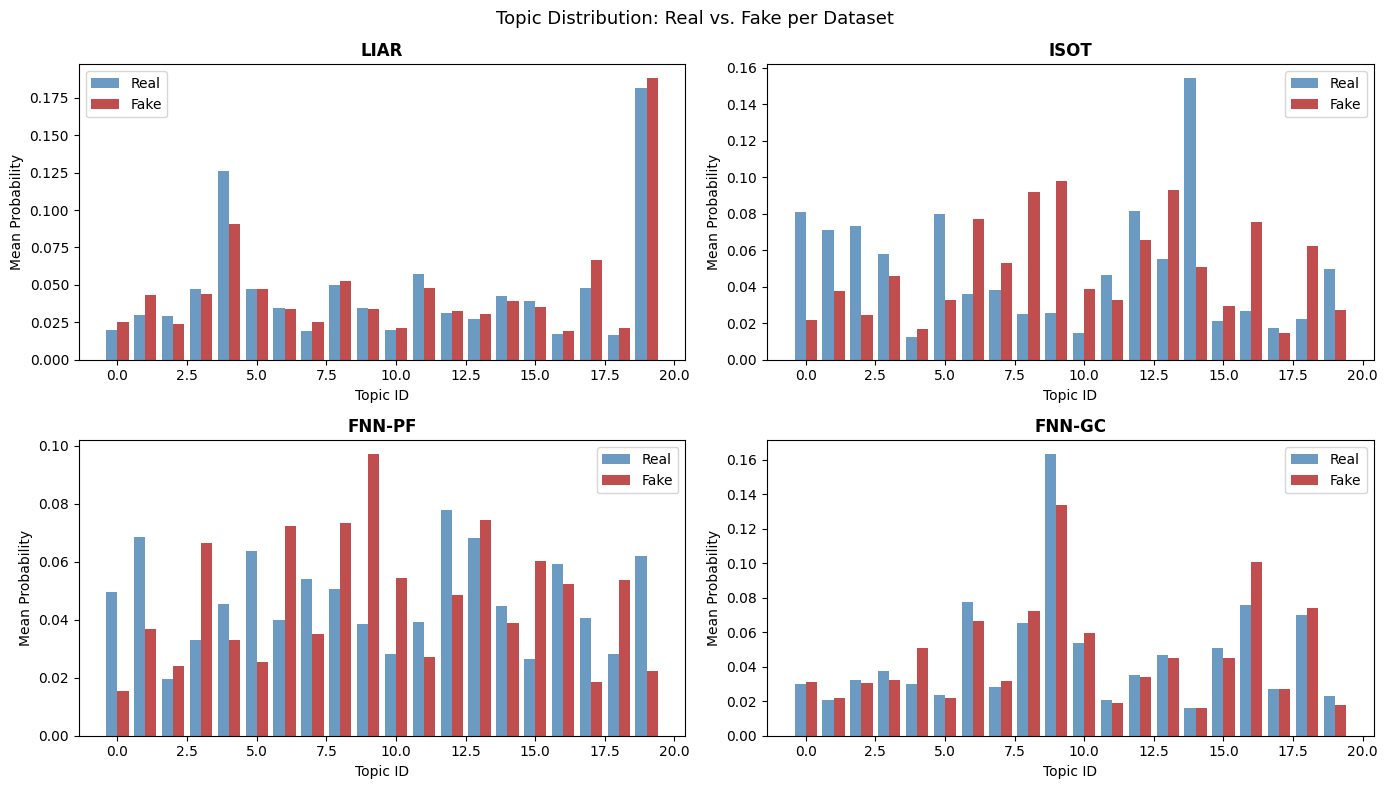

In [ ]:
# ── Visualize topic distributions per dataset ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, name in zip(axes.flatten(), DS_NAMES):
    real_dist = label_topic_dists[name][0]
    fake_dist = label_topic_dists[name][1]
    x = np.arange(N_TOPICS)
    ax.bar(x - 0.2, real_dist, 0.4, label='Real', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, fake_dist, 0.4, label='Fake', color='firebrick', alpha=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Topic ID')
    ax.set_ylabel('Mean Probability')
    ax.legend()

plt.suptitle('Topic Distribution: Real vs. Fake per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('topic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Linguistic Bias Analysis — VOR, Readability, Stylometrics

In [ ]:
import re, string
from nltk import sent_tokenize, word_tokenize

FIRST_PERSON = {'i','me','my','mine','myself','we','us','our','ours','ourselves'}

def stylometric_features(text):
    """Return dict of stylometric features for a single text."""
    text = str(text)
    sents = sent_tokenize(text)
    words = word_tokenize(text.lower())
    words_alpha = [w for w in words if w.isalpha()]
    n_words = max(len(words_alpha), 1)
    n_sents = max(len(sents), 1)

    ttr = len(set(words_alpha)) / n_words
    avg_sent_len = n_words / n_sents
    punct_density = sum(1 for c in text if c in string.punctuation) / max(len(text), 1)
    fp_rate = sum(1 for w in words_alpha if w in FIRST_PERSON) / n_words
    try:
        fk_grade = textstat.flesch_kincaid_grade(text)
    except:
        fk_grade = 0.0

    return {
        'avg_sent_len': avg_sent_len,
        'ttr': ttr,
        'punct_density': punct_density,
        'fp_rate': fp_rate,
        'fk_grade': fk_grade,
    }

# Compute features for all datasets
stylo_data = {}  # name -> DataFrame of features
for name, (train_df, test_df) in DATASETS.items():
    df = pd.concat([train_df, test_df]).reset_index(drop=True)
    print(f'Computing stylometrics for {name} ({len(df)} texts)...')
    feats = df['text'].apply(stylometric_features).apply(pd.Series)
    feats['label'] = df['binary_label'].values
    stylo_data[name] = feats

print('Done.')

Computing stylometrics for LIAR (11507 texts)...
Computing stylometrics for ISOT (8000 texts)...
Computing stylometrics for FNN-PF (1056 texts)...
Computing stylometrics for FNN-GC (8000 texts)...
Done.


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# ── Readability Gap (FK grade: real vs fake) ──────────────────────────────────
print('Readability Gap (Flesch-Kincaid grade level: fake − real):')
rg_data = {}
for name, feats in stylo_data.items():
    fk_real = feats[feats['label']==0]['fk_grade'].mean()
    fk_fake = feats[feats['label']==1]['fk_grade'].mean()
    rg = fk_fake - fk_real
    rg_data[name] = rg
    print(f'  {name}: FK_real={fk_real:.2f}  FK_fake={fk_fake:.2f}  gap={rg:+.2f}')

# ── Vocabulary Overlap Ratio (Jaccard, top-10k words) ────────────────────────
print('\nVocabulary Overlap Ratio (Jaccard of top-10k words):')
top_k = 10_000
vocabs = {}
for name, (train_df, test_df) in DATASETS.items():
    counter = Counter()
    for t in pd.concat([train_df, test_df])['text']:
        counter.update(str(t).lower().split())
    vocabs[name] = set(w for w, _ in counter.most_common(top_k))

vor_matrix = pd.DataFrame(index=DS_NAMES, columns=DS_NAMES, dtype=float)
for a in DS_NAMES:
    for b in DS_NAMES:
        inter = len(vocabs[a] & vocabs[b])
        union = len(vocabs[a] | vocabs[b])
        vor_matrix.loc[a, b] = round(inter / union, 4)
print(vor_matrix)

# ── Stylometric Feature Shift (L2 distance between mean vectors) ──────────────
print('\nStylometric feature shift (L2 distance between dataset mean vectors):')
feat_cols = ['avg_sent_len','ttr','punct_density','fp_rate']
mean_vecs = {}
for name, feats in stylo_data.items():
    mean_vecs[name] = feats[feat_cols].mean().values

stylo_matrix = pd.DataFrame(index=DS_NAMES, columns=DS_NAMES, dtype=float)
for a in DS_NAMES:
    for b in DS_NAMES:
        l2 = np.linalg.norm(mean_vecs[a] - mean_vecs[b])
        stylo_matrix.loc[a, b] = round(l2, 4)
print(stylo_matrix)

Readability Gap (Flesch-Kincaid grade level: fake − real):
  LIAR: FK_real=9.41  FK_fake=9.63  gap=+0.22
  ISOT: FK_real=13.28  FK_fake=11.62  gap=-1.66
  FNN-PF: FK_real=9.05  FK_fake=9.36  gap=+0.30
  FNN-GC: FK_real=8.02  FK_fake=8.42  gap=+0.41

Vocabulary Overlap Ratio (Jaccard of top-10k words):
          LIAR    ISOT  FNN-PF  FNN-GC
LIAR    1.0000  0.3887  0.1732  0.1529
ISOT    0.3887  1.0000  0.2037  0.1977
FNN-PF  0.1732  0.2037  1.0000  0.1325
FNN-GC  0.1529  0.1977  0.1325  1.0000

Stylometric feature shift (L2 distance between dataset mean vectors):
           LIAR     ISOT   FNN-PF   FNN-GC
LIAR     0.0000  13.7112   6.7872   5.1648
ISOT    13.7112   0.0000  20.4974  18.8755
FNN-PF   6.7872  20.4974   0.0000   1.6227
FNN-GC   5.1648  18.8755   1.6227   0.0000


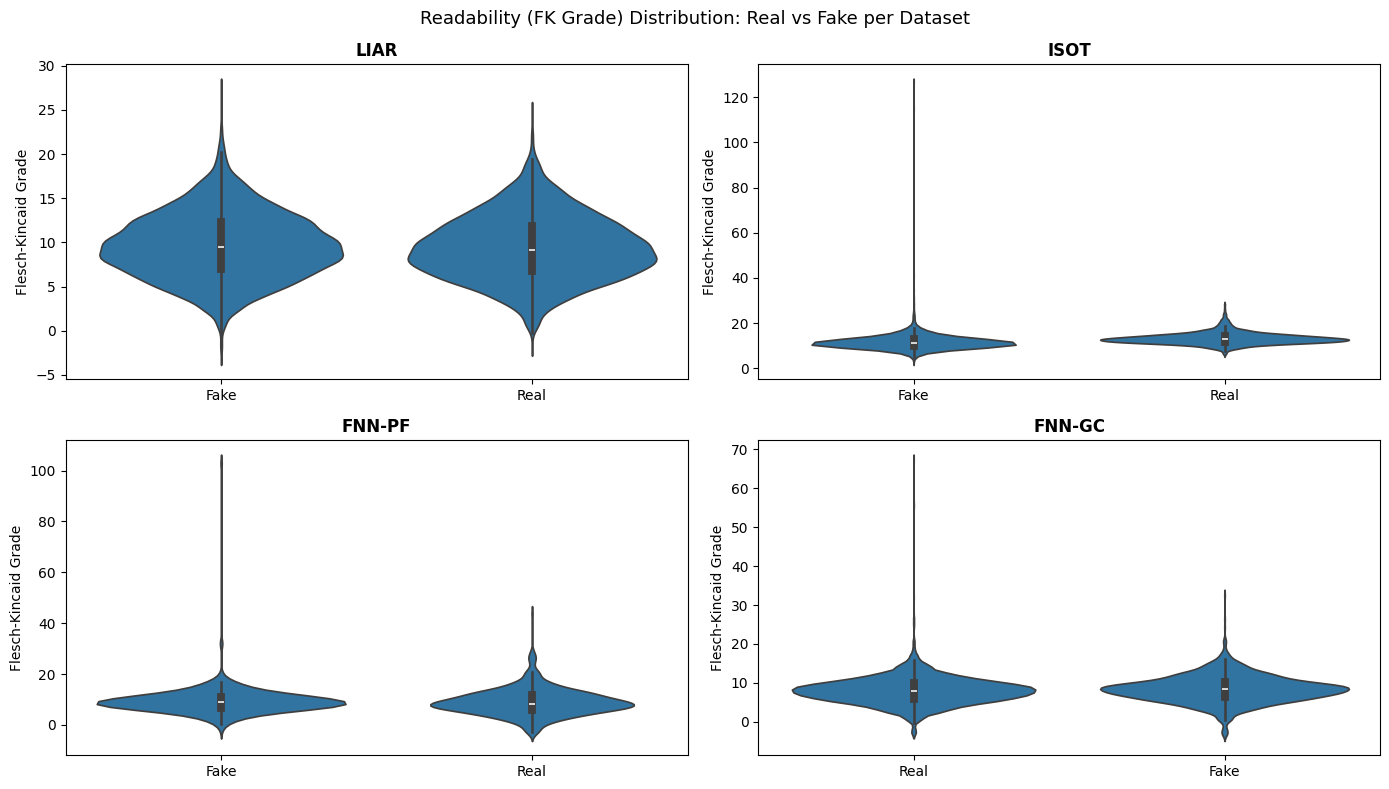

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, name in zip(axes.flatten(), DS_NAMES):
    feats = stylo_data[name].copy()
    feats['class'] = feats['label'].map({0:'Real', 1:'Fake'})

    sns.violinplot(
        data=feats,
        x='class',
        y='fk_grade',
        ax=ax,
        inner='box'   # shows mini boxplot inside violin (nice touch)
    )

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Flesch-Kincaid Grade')

plt.suptitle('Readability (FK Grade) Distribution: Real vs Fake per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('readability_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bias–Performance Correlation Analysis

In [ ]:
# Build a flat dataframe: one row per (model, train_ds, test_ds) with CPD + bias measures
correlation_rows = []

for m in MODEL_NAMES:
    for train_ds in DS_NAMES:
        within_f1, _ = get_f1(m, train_ds, train_ds)
        for test_ds in DS_NAMES:
            if train_ds == test_ds: continue
            cross_f1, _ = get_f1(m, train_ds, test_ds)
            if np.isnan(cross_f1): continue

            cpd = within_f1 - cross_f1

            # Topic bias measures
            cross_jsd = jsd_matrix.loc[train_ds, test_ds]
            within_jsd_train = jensenshannon(
                label_topic_dists[train_ds][0] + 1e-10,
                label_topic_dists[train_ds][1] + 1e-10
            )

            # Linguistic bias measures
            vor = vor_matrix.loc[train_ds, test_ds]
            stylo_shift = stylo_matrix.loc[train_ds, test_ds]
            rg_train = abs(rg_data[train_ds])

            correlation_rows.append({
                'model': m, 'train': train_ds, 'test': test_ds,
                'cpd': cpd,
                'cross_topic_jsd': float(cross_jsd),
                'within_label_jsd': within_jsd_train,
                'vocab_overlap_ratio': float(vor),
                'stylo_shift': float(stylo_shift),
                'readability_gap': rg_train,
            })

corr_df = pd.DataFrame(correlation_rows)

bias_cols = ['cross_topic_jsd','within_label_jsd','vocab_overlap_ratio',
             'stylo_shift','readability_gap']

print('Pearson correlation with CPD:\n')
for col in bias_cols:
    r, p = pearsonr(corr_df['cpd'].dropna(), corr_df[col].dropna())
    print(f'  {col:<28}: r={r:+.3f}  p={p:.4f}')

print('\nSpearman correlation with CPD:\n')
for col in bias_cols:
    r, p = spearmanr(corr_df['cpd'].dropna(), corr_df[col].dropna())
    print(f'  {col:<28}: rho={r:+.3f}  p={p:.4f}')

Pearson correlation with CPD:

  cross_topic_jsd             : r=-0.032  p=0.8070
  within_label_jsd            : r=+0.626  p=0.0000
  vocab_overlap_ratio         : r=+0.081  p=0.5363
  stylo_shift                 : r=+0.426  p=0.0007
  readability_gap             : r=+0.813  p=0.0000

Spearman correlation with CPD:

  cross_topic_jsd             : rho=+0.014  p=0.9183
  within_label_jsd            : rho=+0.492  p=0.0001
  vocab_overlap_ratio         : rho=+0.191  p=0.1437
  stylo_shift                 : rho=+0.298  p=0.0210
  readability_gap             : rho=+0.699  p=0.0000


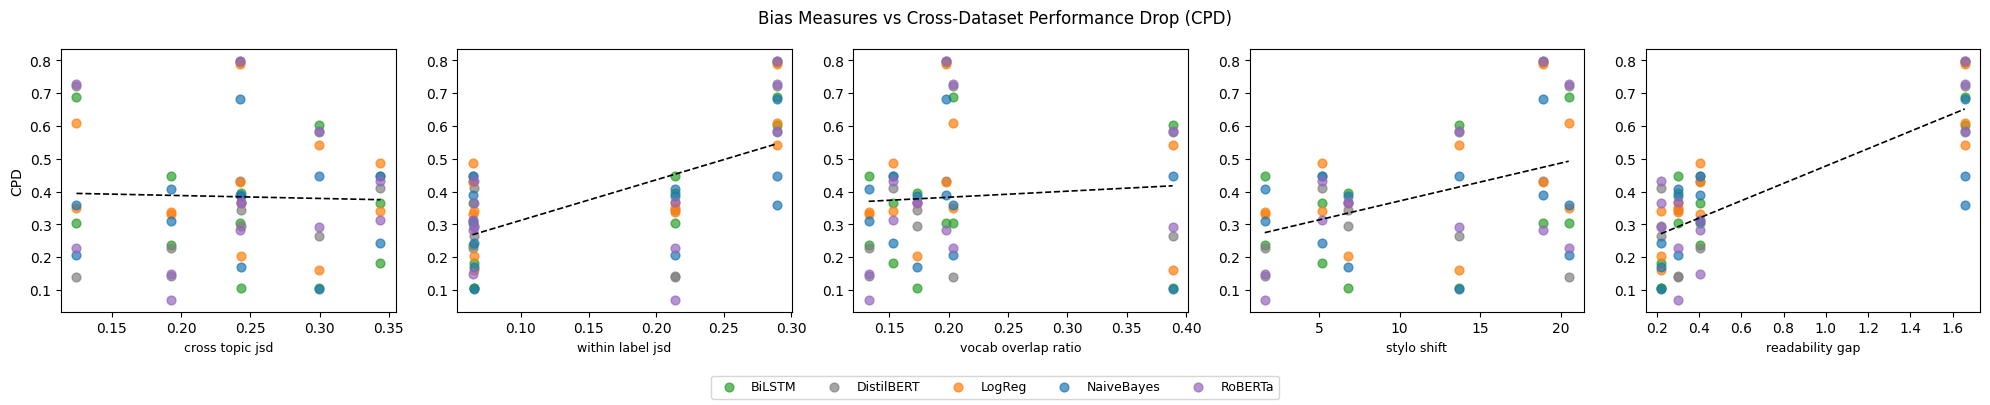

In [ ]:
# ── Scatter: CPD vs each bias measure, colored by model ───────────────────────
fig, axes = plt.subplots(1, len(bias_cols), figsize=(20, 4))
palette = {'NaiveBayes':'#1f77b4','LogReg':'#ff7f0e',
           'BiLSTM':'#2ca02c','BERT':'#d62728','RoBERTa':'#9467bd'}

for ax, col in zip(axes, bias_cols):
    for model, grp in corr_df.groupby('model'):
        ax.scatter(grp[col], grp['cpd'], label=model,
                   color=palette.get(model,'gray'), alpha=0.7, s=40)
    # Trend line
    x = corr_df[col].values
    y = corr_df['cpd'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    z = np.polyfit(x[mask], y[mask], 1)
    xl = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'k--', linewidth=1.2)
    ax.set_xlabel(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('CPD' if ax == axes[0] else '')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc='lower center', ncol=5, fontsize=9)
plt.suptitle('Bias Measures vs Cross-Dataset Performance Drop (CPD)', fontsize=12)
plt.tight_layout(rect=[0,0.08,1,1])
plt.savefig('bias_cpd_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Dataset Bias Scorecard

In [ ]:
from scipy.stats import entropy as scipy_entropy

def topic_concentration_score(ds_name):
    """Lower entropy = higher concentration = higher risk. Return 1 - normalized_entropy."""
    dist = ds_topic_dists[ds_name] + 1e-10
    max_entropy = np.log(N_TOPICS)
    return 1 - (scipy_entropy(dist) / max_entropy)  # 0=uniform, 1=single topic

def label_topic_confound_score(ds_name):
    """JSD between real and fake topic distributions. Higher = more confounded."""
    r = label_topic_dists[ds_name][0] + 1e-10
    f = label_topic_dists[ds_name][1] + 1e-10
    return jensenshannon(r, f)

def stylometric_discriminability_score(ds_name):
    """F1 of LR trained on stylometric features only. Higher = more dataset-specific."""
    feats = stylo_data[ds_name]
    X = feats[['avg_sent_len','ttr','punct_density','fp_rate','fk_grade']].values
    y = feats['label'].values
    split = int(0.8 * len(X))
    clf = LogisticRegression(max_iter=500).fit(X[:split], y[:split])
    preds = clf.predict(X[split:])
    return f1_score(y[split:], preds, average='macro')

def risk_level(tcs, ltcs, sds):
    score = tcs + ltcs + (sds - 0.5) * 2
    if score > 1.5: return 'HIGH'
    if score > 0.8: return 'MEDIUM'
    return 'LOW'

print('Dataset Bias Scorecard\n' + '='*60)
scorecard = []
for name in DS_NAMES:
    tcs  = topic_concentration_score(name)
    ltcs = label_topic_confound_score(name)
    sds  = stylometric_discriminability_score(name)
    risk = risk_level(tcs, ltcs, sds)
    scorecard.append({'Dataset': name, 'TCS': round(tcs,3),
                      'LTCS': round(ltcs,3), 'SDS': round(sds,3), 'Risk': risk})
    print(f'{name:<12}  TCS={tcs:.3f}  LTCS={ltcs:.3f}  SDS={sds:.3f}  → {risk} RISK')

scorecard_df = pd.DataFrame(scorecard)
scorecard_df

Dataset Bias Scorecard
LIAR          TCS=0.075  LTCS=0.065  SDS=0.397  → LOW RISK
ISOT          TCS=0.028  LTCS=0.289  SDS=0.748  → MEDIUM RISK
FNN-PF        TCS=0.012  LTCS=0.214  SDS=0.675  → LOW RISK
FNN-GC        TCS=0.063  LTCS=0.064  SDS=0.427  → LOW RISK


,Dataset,TCS,LTCS,SDS,Risk
0,LIAR,0.075,0.065,0.397,LOW
1,ISOT,0.028,0.289,0.748,MEDIUM
2,FNN-PF,0.012,0.214,0.675,LOW
3,FNN-GC,0.063,0.064,0.427,LOW


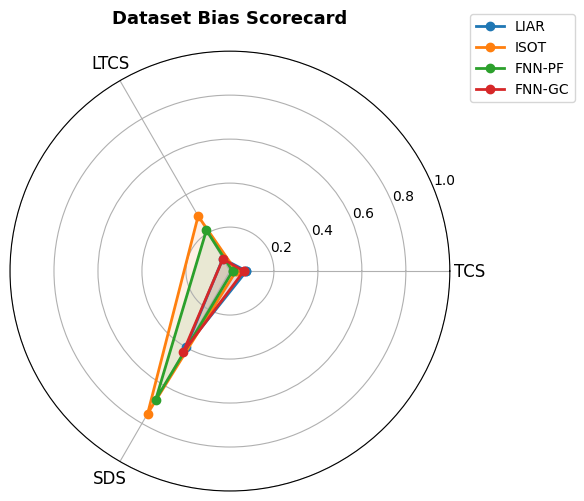

In [ ]:
# ── Radar chart for the scorecard ─────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

categories = ['TCS', 'LTCS', 'SDS']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

for i, row in scorecard_df.iterrows():
    vals = [row['TCS'], row['LTCS'], row['SDS']]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=row['Dataset'], color=colors[i])
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Dataset Bias Scorecard', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('bias_scorecard_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Results Summary

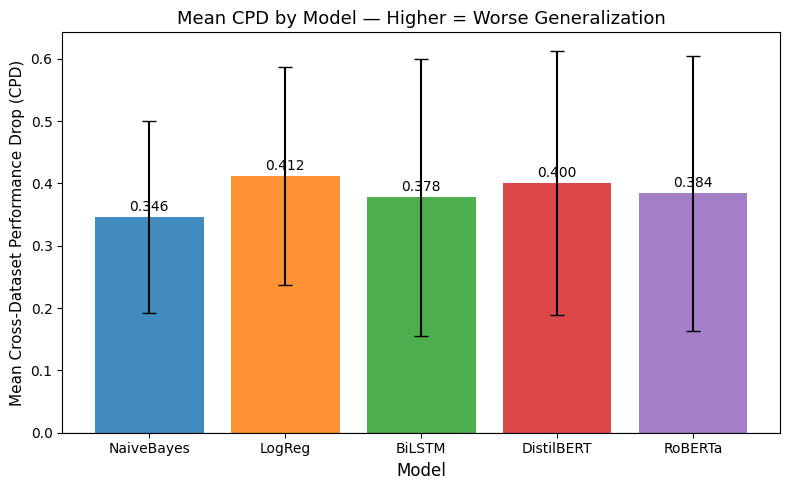


All results computed. Figures saved:
  cpd_heatmap.png
  topic_distributions.png
  readability_gap.png
  bias_cpd_scatter.png
  bias_scorecard_radar.png
  mean_cpd_by_model.png


In [ ]:
# ── Bar chart: mean CPD per model ─────────────────────────────────────────────
mean_cpd = cpd_df.groupby('model')['cpd'].mean().reindex(MODEL_NAMES)
std_cpd  = cpd_df.groupby('model')['cpd'].std().reindex(MODEL_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(MODEL_NAMES, mean_cpd.values, yerr=std_cpd.values,
              color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'],
              capsize=5, alpha=0.85)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Mean Cross-Dataset Performance Drop (CPD)', fontsize=11)
ax.set_title('Mean CPD by Model — Higher = Worse Generalization', fontsize=13)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, mean_cpd.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('mean_cpd_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll results computed. Figures saved:')
for f in ['cpd_heatmap.png','topic_distributions.png','readability_gap.png',
          'bias_cpd_scatter.png','bias_scorecard_radar.png','mean_cpd_by_model.png']:
    print(f'  {f}')

In [ ]:
# ── Export all numerical results to CSV ───────────────────────────────────────
rows = []
for (model, train_ds, test_ds), scores in all_results.items():
    rows.append({
        'model': model, 'train': train_ds, 'test': test_ds,
        'f1_mean': round(np.mean(scores), 4),
        'f1_std':  round(np.std(scores), 4),
        'within_dataset': train_ds == test_ds,
    })

results_df = pd.DataFrame(rows).sort_values(['model','train','test'])
results_df.to_csv('all_results.csv', index=False)
print('Results saved to all_results.csv')
results_df.head(20)

Results saved to all_results.csv


,model,train,test,f1_mean,f1_std,within_dataset
47,BiLSTM,FNN-GC,FNN-GC,0.7599,0.0037,True
46,BiLSTM,FNN-GC,FNN-PF,0.5243,0.0360,False
45,BiLSTM,FNN-GC,ISOT,0.4567,0.0141,False
44,BiLSTM,FNN-GC,LIAR,0.3937,0.0383,False
43,BiLSTM,FNN-PF,FNN-GC,0.3872,0.0714,False
42,BiLSTM,FNN-PF,FNN-PF,0.8353,0.0289,True
41,BiLSTM,FNN-PF,ISOT,0.5318,0.0637,False
40,BiLSTM,FNN-PF,LIAR,0.4397,0.0593,False
39,BiLSTM,ISOT,FNN-GC,0.2054,0.0034,False
38,BiLSTM,ISOT,FNN-PF,0.3110,0.0190,False
